# Network Statistics

## Overview

Network-level statistics characterise overall topology and compare observed networks to null models. They distinguish random connectivity from biologically structured patterns.

**Key statistics:**

| Statistic | Meaning | Ecological relevance |
|---|---|---|
| Density | Edge fraction of possible | Interaction completeness |
| Clustering coefficient | Triangle density | Functional redundancy |
| Average path length | Mean inter-node distance | Dispersal efficiency |
| Degree distribution | How connections are spread | Hub dominance |
| Assortativity | Rich-get-richer tendency | Robustness to attack |
| Small-world index | Clustered yet short paths | Resilience signature |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

rng = np.random.default_rng(42)

# Build three ecological networks with different topologies
# 1. Random (Erdos-Renyi)
G_rand  = nx.erdos_renyi_graph(30, 0.15, seed=42)
# 2. Scale-free (Barabasi-Albert) -- realistic for species interactions
G_sf    = nx.barabasi_albert_graph(30, 2, seed=42)
# 3. Small-world (Watts-Strogatz) -- realistic for dispersal networks
G_sw    = nx.watts_strogatz_graph(30, 4, 0.3, seed=42)

graphs = {'Random (ER)': G_rand, 'Scale-free (BA)': G_sf, 'Small-world (WS)': G_sw}
print(f"{'Network':20s} {'Nodes':>6} {'Edges':>6} {'Density':>9} {'Avg degree':>11}")
for name, G in graphs.items():
    deg = np.mean([d for n,d in G.degree()])
    print(f"{name:20s} {G.number_of_nodes():6d} {G.number_of_edges():6d} "
          f"{nx.density(G):9.4f} {deg:11.2f}")

Network               Nodes  Edges   Density  Avg degree
Random (ER)              30     61    0.1402        4.07
Scale-free (BA)          30     56    0.1287        3.73
Small-world (WS)         30     60    0.1379        4.00


---
## Clustering and Path Length

In [2]:
def network_stats(G, name):
    lcc = G.subgraph(max(nx.connected_components(G), key=len))
    c   = nx.average_clustering(lcc)
    l   = nx.average_shortest_path_length(lcc)
    # Compare to equivalent random graph
    n, m = lcc.number_of_nodes(), lcc.number_of_edges()
    p_rand = 2*m / (n*(n-1))
    c_rand = p_rand
    l_rand = np.log(n) / np.log(p_rand * n) if p_rand * n > 1 else np.nan
    sw_idx = (c/c_rand) / (l/l_rand) if l_rand else np.nan
    return {'Network': name, 'C (observed)': round(c,4), 'C (random)': round(c_rand,4),
            'L (observed)': round(l,4), 'L (random)': round(l_rand,4),
            'Small-world index': round(sw_idx,3)}

rows = [network_stats(G, name) for name, G in graphs.items()]
stats_df = pd.DataFrame(rows)
print(stats_df.to_string(index=False))
print("\nSmall-world network: high clustering (C >> C_rand) AND short paths (L ~ L_rand)")
print("SW index >> 1 indicates small-world topology")

         Network  C (observed)  C (random)  L (observed)  L (random)  Small-world index
     Random (ER)        0.1337      0.1402        2.4644      2.3673              0.916
 Scale-free (BA)        0.3002      0.1287        2.1816      2.5172              2.691
Small-world (WS)        0.1965      0.1379        2.6069      2.3949              1.309

Small-world network: high clustering (C >> C_rand) AND short paths (L ~ L_rand)
SW index >> 1 indicates small-world topology


---
## Degree Distribution

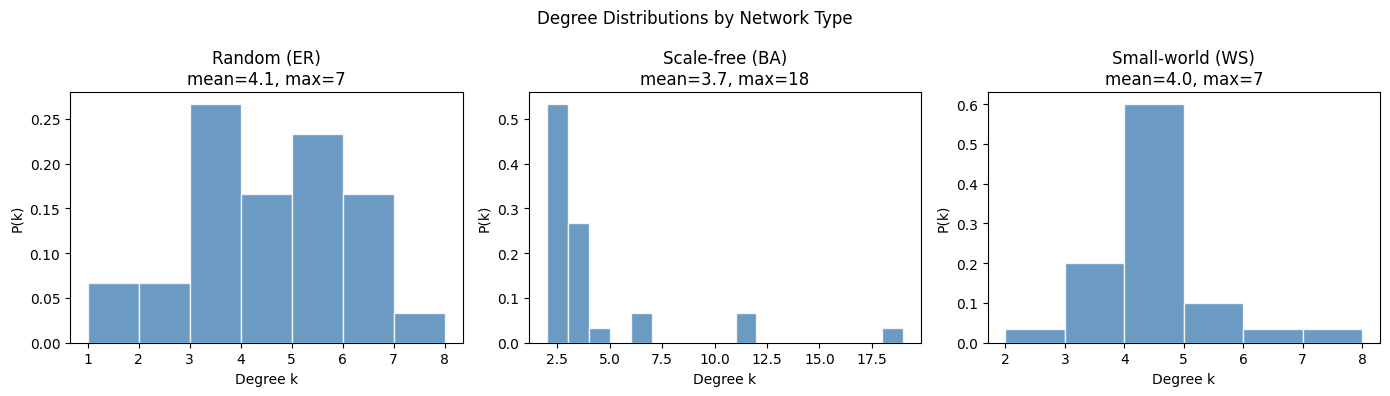

Scale-free network: power-law exponent gamma = 0.672
  R² = 0.922  (close to 1 = good power-law fit)
  Characteristic of BA model; empirically found in food webs, dispersal networks


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, G) in zip(axes, graphs.items()):
    degrees = [d for n,d in G.degree()]
    ax.hist(degrees, bins=range(min(degrees), max(degrees)+2),
            color='steelblue', edgecolor='white', density=True, alpha=0.8)
    ax.set_xlabel('Degree k'); ax.set_ylabel('P(k)')
    ax.set_title(f'{name}\nmean={np.mean(degrees):.1f}, max={max(degrees)}')
plt.suptitle('Degree Distributions by Network Type')
plt.tight_layout(); plt.show()

# Power-law fit for scale-free network
degrees_sf = sorted([d for n,d in G_sf.degree() if d > 0], reverse=True)
log_k  = np.log(range(1, len(degrees_sf)+1))
log_d  = np.log(degrees_sf)
slope, intercept, r, p, se = stats.linregress(log_k, log_d)
print(f"Scale-free network: power-law exponent gamma = {-slope:.3f}")
print(f"  R² = {r**2:.3f}  (close to 1 = good power-law fit)")
print(f"  Characteristic of BA model; empirically found in food webs, dispersal networks")

---
## Assortativity and Robustness

Random (ER)         : assortativity = -0.0525
Scale-free (BA)     : assortativity = -0.4781
Small-world (WS)    : assortativity = -0.0460

Positive = assortative (hubs connect to hubs): more robust to targeted attack
Negative = disassortative (hubs connect to low-degree): more fragile


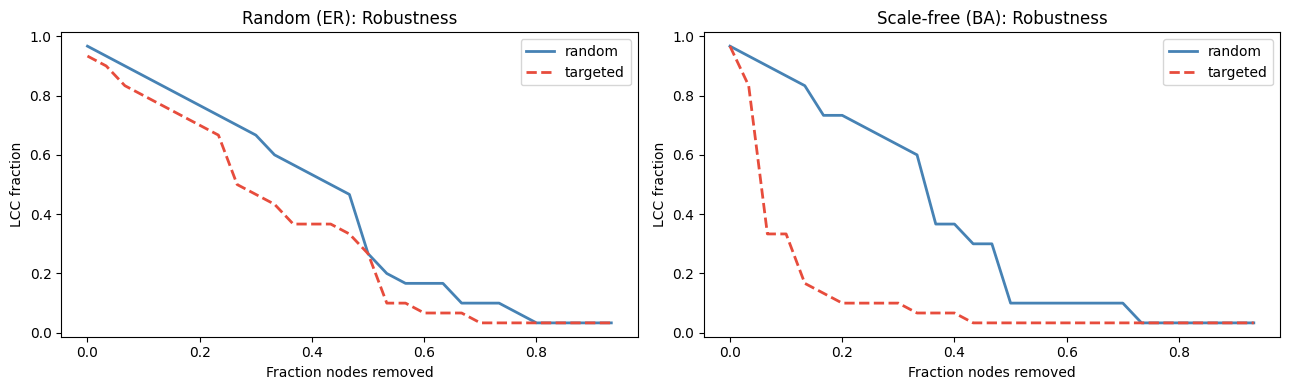

In [4]:
# Assortativity: do high-degree nodes connect to high-degree nodes?
for name, G in graphs.items():
    assort = nx.degree_assortativity_coefficient(G)
    print(f"{name:20s}: assortativity = {assort:.4f}")
print("\nPositive = assortative (hubs connect to hubs): more robust to targeted attack")
print("Negative = disassortative (hubs connect to low-degree): more fragile")

# Robustness simulation: targeted vs random node removal
def robustness_sim(G_orig, strategy='random', n_steps=20):
    G_temp = G_orig.copy()
    n0     = G_temp.number_of_nodes()
    fracs, lcc_fracs = [], []
    step   = max(1, n0 // n_steps)
    nodes_to_remove = list(G_temp.nodes())
    if strategy == 'targeted':
        nodes_to_remove = sorted(nodes_to_remove,
            key=lambda n: G_orig.degree(n), reverse=True)
    else:
        rng.shuffle(nodes_to_remove)
    for i, node in enumerate(nodes_to_remove):
        if G_temp.has_node(node):
            G_temp.remove_node(node)
        if i % step == 0 and G_temp.number_of_nodes() > 0:
            lcc = len(max(nx.connected_components(G_temp), key=len))
            fracs.append(i / n0)
            lcc_fracs.append(lcc / n0)
    return fracs, lcc_fracs

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, G) in zip(axes, list(graphs.items())[:2]):
    for strat, color, ls in [('random','steelblue','-'), ('targeted','#e74c3c','--')]:
        f, lcc = robustness_sim(G.copy(), strat)
        ax.plot(f, lcc, lw=2, color=color, linestyle=ls, label=strat)
    ax.set_xlabel('Fraction nodes removed'); ax.set_ylabel('LCC fraction')
    ax.set_title(f'{name}: Robustness'); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
# Null model comparison: is observed clustering higher than random?
def null_model_test(G_obs, n_rewire=1000, n_null=100):
    obs_c = nx.average_clustering(G_obs)
    null_c = []
    for _ in range(n_null):
        G_null = G_obs.copy()
        nx.double_edge_swap(G_null, nswap=n_rewire, max_tries=n_rewire*10)
        null_c.append(nx.average_clustering(G_null))
    z_score = (obs_c - np.mean(null_c)) / (np.std(null_c) + 1e-10)
    p_value = (np.array(null_c) >= obs_c).mean()
    return obs_c, np.array(null_c), z_score, p_value

print("Null model test: is observed clustering significantly higher than random?")
for name, G in graphs.items():
    lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    if lcc.number_of_edges() > 5:
        obs_c, null_cs, z, p = null_model_test(lcc, n_rewire=200, n_null=50)
        print(f"  {name:20s}: C_obs={obs_c:.4f}, C_null={null_cs.mean():.4f}±{null_cs.std():.4f}, z={z:.2f}, p={p:.3f}")

Null model test: is observed clustering significantly higher than random?
  Random (ER)         : C_obs=0.1337, C_null=0.1132±0.0354, z=0.58, p=0.300
  Scale-free (BA)     : C_obs=0.3002, C_null=0.4049±0.0742, z=-1.41, p=0.900
  Small-world (WS)    : C_obs=0.1965, C_null=0.0886±0.0346, z=3.12, p=0.000


---

## Common Pitfalls

**1. Computing network statistics on the full graph when it is disconnected**  
`nx.average_shortest_path_length()` raises `NetworkXError` if the graph is not connected, because path lengths are undefined between disconnected components. Always extract the largest connected component first: `lcc = G.subgraph(max(nx.connected_components(G), key=len))`.

**2. Concluding "small-world topology" from high clustering alone**  
Small-world networks are characterised by high clustering *and* short average path lengths — both conditions must hold simultaneously relative to a random graph with the same size and density. High clustering alone is not sufficient; many real networks with local spatial structure show high clustering but long paths.

**3. Fitting a power-law to degree distribution by eye without statistical testing**  
A heavy-tailed distribution that looks linear on a log-log plot is not necessarily a power law — lognormal and stretched exponential distributions produce similar visual patterns. Always use maximum likelihood fitting and statistical tests (e.g. Clauset et al. method via `powerlaw` library) before claiming scale-free topology.

**4. Using assortativity coefficient without checking for degree-degree correlation significance**  
With small networks (n < 100), assortativity coefficients can be substantially non-zero by chance. Always compare the observed coefficient to a null distribution generated by degree-preserving rewiring.

**5. Removing nodes sequentially in robustness analysis without recalculating degree after each removal**  
In targeted attack simulations, the highest-degree node should be recalculated after each removal — removing one hub changes the degree of its neighbours. Static pre-sorting (remove top-k by original degree) underestimates fragility of scale-free networks and overestimates robustness.

---
*python_methods_library - Samantha McGarrigle*